# Homework 3: Working with data using Pandas and Fitting data with a model

### <p style="text-align: right;"> &#9989; Put your name here.


<img src="https://www.lifegate.com/app/uploads/wine-grapes.jpg"
     alt="Image of grapevines"
     align="center" 
     height="1000" 
     width="600" />
     
Image credit: https://www.lifegate.com/people/news/climate-change-wine-production


## Goals

### By the end of the homework assignment you will have practiced:

1. Reading and visualizing data with `pandas`
2. Fitting data using `curve_fit`
3. Modeling harvest date as a function of temperature and year and finding best fit parameters
4. Building a simple Python class and inheriting that class to create a new class

## Assignment instructions

Work through the following assignment, making sure to follow all of the directions and answer all of the questions.

**This assignment is due at 11:59pm on Frida, Nov 14.** It should be uploaded into the "Homework Assignments" submission folder for Homework #4.  Submission instructions can be found at the end of the notebook.

**Full disclosure**: The first two parts of this exam were created in collaboration with a professor in horticulture with an interest in wine and I am an expert in neither!

## Grading

* Exploring the grape harvest data (**18 points**)
    - 1.1 Loading and inspecting the data (5 points)
    - 1.2 Determining the earliest and latest harvest dates and where they occurred (5 points)
    - 1.3 Finding median harvest dates in 50 year intervals (4 points)
    - 1.4 Visualizing trends by region (3 points)
    - 1.5 Looking for correlation in harvest date between Burgundy and Switzerland (4 points)
* Modeling grape harvest dates and climate change (**17 points**)
    - Graphing temperature anomaly vs year and harvest date vs temperature anomaly (3 points)
    - Modeling harvest date as a function of temperature anomaly using `curve_fit` (7 points)
    - Graphing harvest date vs year (2 point)
    - Modeling harvest date as a function year using `polyfit` (5 points)
* Writing a simple Python class (**15 points**)
    - Enhancing and using a pre-existing class (10 points)
    - Inheriting a class (5 points)
    
**Total**: 50 points

---
## Part 1: Exploring the grape harvest data (18 points total)

### 1.1: Loading and inspecting the data (5 points)

After visiting Traverse City and sampling Michigan wines, you decide that you would like to start a vineyard in Michigan. You've seen the vineyards in Traverse City and know that, although it is possible to grow wine grapes there, that sometimes it is too cold. You wonder if because of climate change, Michigan might soon have a warmer, more suitable climate for growing grapes. 

You know that Europe has a long history of growing grapes, and you wonder if they kept records that might indicate how grapes respond to changes in temperature. You find a [study](https://www.clim-past.net/8/1403/2012/cp-8-1403-2012.pdf) that has compiled numerous records of grape harvest dates for more than four centuries and also a [database](http://www.climatemonitor.it/?page_id=40210&lang=en) of temperature anomalies in Europe dating back to 1655.

Using the provided dataset, `grape_harvest.csv`, you're going to explore how the European grape harvest date changes with respect to temperature across centuries of data.

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

&#9989; **Task: (1 point)** Read in the grape harvest data file as a pandas dataframe.

In [5]:
# Read in the grape harvest data here


In [6]:
### ANSWER ###

# Read in the grape harvest data here
data = pd.read_csv("grape_harvest.csv")

&#9989; **Task: (4 points)** Now, write some code to inspect the properties of the data and then answer the following questions:

* Use a command to look at the first five lines of data
* Use a command to look at summary statistics (like the count, min, max, and mean) for columns with continuous data
* What are the names of the columns?
* How many rows are in this dataset?

In [ ]:
# Put your code here


*Put your answer here*

In [4]:
### ANSWER ###
data.head()
data.describe()
data.info()
# 1 point for each correct answer, 0 for incorrect answer
# Q1. Use head()
# Q2. Use describe()
# Q3. 'year', 'region', 'harvest', 'anomaly'. Note that described does not have region because it is a categorical variable
# Q4. 4732. Can also use code to get the answer. 

,year,region,harvest,anomaly
0,1700,alsace,42.9,-0.91
1,1701,alsace,35.9,-0.76
2,1702,alsace,45.0,-1.40
3,1703,alsace,49.4,-1.21
4,1704,alsace,30.4,-0.44


In [5]:
### ANSWER ###
data.describe()

,year,harvest,anomaly
count,4732.000000,4732.000000,4732.000000
mean,1832.835376,33.959510,-0.337811
std,91.713152,11.807714,0.675309
min,1655.000000,-13.000000,-2.470000
25%,1762.000000,25.900000,-0.750000
50%,1834.500000,34.000000,-0.280000
75%,1903.000000,42.600000,0.060000
max,2007.000000,75.000000,1.460000


### 1.2: Determining the earliest and latest harvest dates and where they occurred (5 points)

The `pandas` dataframe you just created should have four columns, which are:

* **'year'**: the year the data was collected
* **'region'**: the region in Europe that the data was collected from
* **'harvest'**: the harvest date recorded. Harvest date is defined as number of days after August 31st. A negative number means the grapes were harvested before August 31st that year, and a positive number after.
* **'anomaly'**: the temperature anomaly. For a given year, this number represents how much colder (negative) or hotter (positive) Europe was compared to a long term reference value, in degrees Celsius

We'll start off our exploration of grape harvest dates by figuring out when and where the earliest and latest harvest dates occurred.

&#9989; **Task:** Below, print out statements answering the following questions using masking techniques that you have learned:

1) **Which year did the earliest harvest happen, which region did it occur in, and how early was the harvest?**

2) **Which year did the latest harvest happen, which region did it occur in, and how late was the harvest?**

In [ ]:
# Put your code here


*Put your answer here*

In [13]:
### ANSWER ###
year = data['year'][data['harvest'] == data['harvest'].min()].values[0]
region = data['region'][data['harvest'] == data['harvest'].min()].values[0]
days = data['harvest'].min()

print(f"The earliest harvest was from the region {region} with {days:.0f} days before August 31st in year {year}")
# 3 points for getting region,days,year correct (1 point each) 
# 1 point for printing a full sentence

The earliest harvest was from the region champagne_2 with -13 days before August 31st in year 1822


In [15]:
### ANSWER ###
year = data['year'][data['harvest'] == data['harvest'].max()].values[0]
region = data['region'][data['harvest'] == data['harvest'].max()].values[0]
days = data['harvest'].max()

print(f"The earliest harvest was from the region {region} with {days:.0f} days after August 31st in year {year}")
# 1 point for understanding that they need to use max instead of min. 


The earliest harvest was from the region luxembourg with 75 days after August 31st in year 1851


### 1.3 Finding median harvest dates in 50 year intervals (5 points)

You want to know if the grape harvest date is changing, and if so, is it getting earlier or later?

You decide that you would like to know the median grape harvest date for the following 50 year intervals, as well as the median since the year 2000:

* 1800-1849
* 1850-1899
* 1900-1949
* 1950-1999
* 2000-2007

&#9989; **Task:** For each of the above intervals, calculate the **median** grape harvest date. For each interval print out statements saying

`"The median harvest date for years (*insert interval here*) is: x"`.

**Is the harvest date for grapes getting earlier or later?**


In [ ]:
# Put your code here


*Put your answer here*

In [24]:
### ANSWER ###

# 1 point for calculating the median and not the mean
# 1 point for printing all the dates.
# 1 point for answering the earlier/later question
# 1 point for using masks
# 1 point for a working code

# Easy solution

# median_1800_1849 = data['harvest'][ (data['year'] >= 1800) & (data['year'] <= 1849) ].median()
# median_1850_1899 = data['harvest'][ (data['year'] >= 1850) & (data['year'] <= 1899) ].median()
# median_1900_1949 = data['harvest'][ (data['year'] >= 1900) & (data['year'] <= 1949) ].median()
# median_1950_1999 = data['harvest'][ (data['year'] >= 1950) & (data['year'] <= 1999) ].median()
# median_2000_2007 = data['harvest'][ (data['year'] >= 2000) & (data['year'] <= 2007) ].median()

# print("The mean harvest date from 1800_1849 was", median_1800_1849)
# print("The mean harvest date from 1850_1899 was", median_1850_1899)
# print("The mean harvest date from 1900_1949 was", median_1900_1949)
# print("The mean harvest date from 1950_1999 was", median_1950_1999)
# print("The mean harvest date from 2000_2007 was", median_2000_2007)

# Expert solution
year = 1800
interval = 50 # years
while year < 2007:
    min_year = year
    max_year = year + interval
    mask = data["year"] >= min_year 
    mask_2 = data["year"] < max_year
    median = data["harvest"][mask & mask_2].median()
    if max_year> 2007:
        max_year = 2007
    print(f"The median harvest day for years {min_year}-{max_year} was {median:.1f}")
    year += interval
    
print(f"The median harvest date is getting earlier")

The median harvest day for years 1800-1850 was 36.0
The median harvest day for years 1850-1900 was 33.8
The median harvest day for years 1900-1950 was 27.9
The median harvest day for years 1950-2000 was 28.0
The median harvest day for years 2000-2007 was 19.9
The median harvest date is getting earlier


### 1.4 Visualizing trends by region (8 points)

Now that you understand a bit about the overall trends in the data, you want to examine other factors that might influence grape harvest date besides historical changes in climate.

You see that the data comes from many regions, all the way from sunny Spain to Germany. You wonder if these latitudinal differences would have any effect on the grape harvest dates.

&#9989; **Task: (5 points)** Make a boxplot comparing the ditributions of grape harvest dates where the x-axis is "region" and the y-axis "harvest". The regions will be ordered by latitude, from the most southern to northern. This will allow you to assess visually if latitude is affecting grape harvest date.

Your plot should:

1. have a figure of size (15, 4)
2. include axis labels
3. have a title
4. the $x$ axis ticks should be rotated by 90 degrees
5. finally, arrange the regions by latitude, from the most southern to the most northern. To do this, use the provided list $latitude\_order$. Within `seaborn` boxplot function, specify the `order` argument as follows: `order = latitude_order`. This will arrange the regions in your boxplot from the most southern to northern.

**Hint:** Here is the [link](https://seaborn.pydata.org/generated/seaborn.boxplot.html#seaborn.boxplot) to `boxplot`'s documentation. You want to get a plot like this

![harvestplot](harvest_plot.png)

In [ ]:
## DO NOT DELETE THE PROVIDED LINES OF CODE

# list of regions, from the most southern to northern 
latitude_order = ['spain','maritime_alps','languedoc','various_south_east',
                  'gaillac_south_west','southern_rhone_valley','bordeaux',
                  'northern_rhone_valley','auvergne','savoie','northern_italy',
                  'beaujolais_maconnais','vendee_poitou_charente','switzerland_leman_lake',
                  'jura','high_loire_valley','low_loire_valley','burgundy','auxerre_avalon',
                  'champagne_2','southern_lorraine','alsace','northern_lorraine',
                  'germany','ile_de_france','champagne_1','luxembourg'] 
                    
# Put your code here


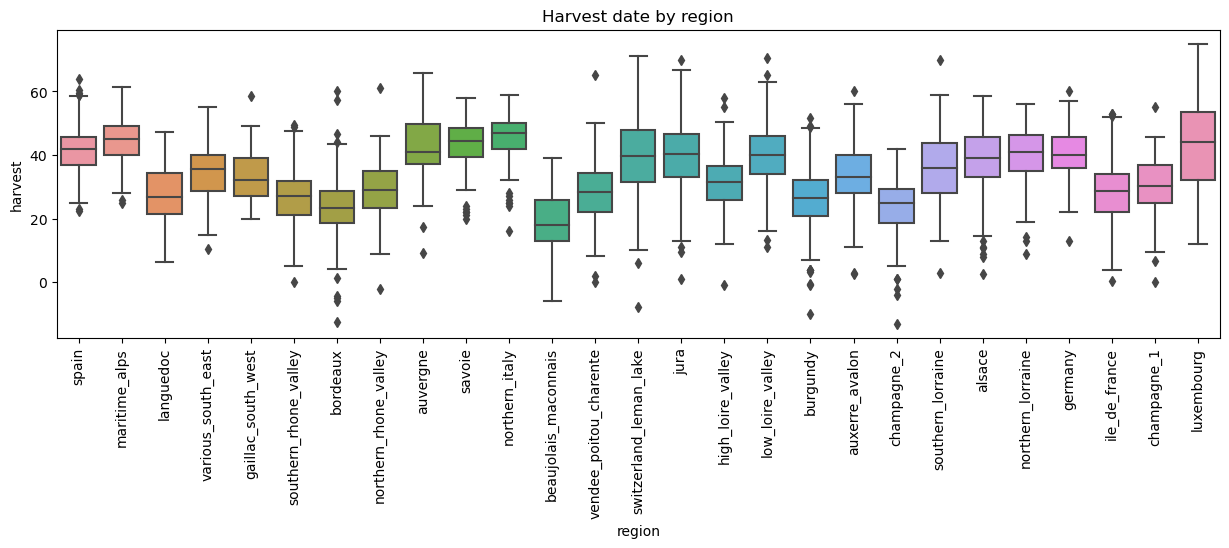

In [34]:
### ANSWER ###
plt.figure(figsize=(15,4))


latitude_order = ['spain','maritime_alps','languedoc','various_south_east','gaillac_south_west','southern_rhone_valley','bordeaux','northern_rhone_valley','auvergne','savoie','northern_italy','beaujolais_maconnais','vendee_poitou_charente','switzerland_leman_lake','jura','high_loire_valley','low_loire_valley','burgundy','auxerre_avalon','champagne_2','southern_lorraine','alsace','northern_lorraine','germany','ile_de_france','champagne_1','luxembourg']

_ = sns.boxplot(x = data['region'], y = data['harvest'], order=latitude_order)
plt.xticks(rotation=90)
# plt.xlabel("region")
# plt.ylabel("harvest date")
plt.title("Harvest date by region")
plt.savefig("harvest_plot.png")

# 1 point for each bullet point 

&#9989; **Question: (3 points)** Based on your graph, do you believe that latitude affects the harvest date? Explain your reasoning. If harvest date changes going south to north, how does this impact your analysis of the effect of history and climate change on harvest date? If harvest date is not affected by latitude, what are the implications for your analysis then?

*Put your response here*

In [36]:
### ANSWER
# 3 points if their answer makes sense. 
# 1 point if their answer doesn't make sense, but at least they answer it.
# 0 point for blank

### 1.5 Looking for correlation in harvest date between Burgundy and Switzerland (11 points)

You wonder if the grape harvest dates in different regions are correlated with each other. Two regions with some of the longest records of grape harvest dates are Burgundy (`burgundy`) and Switzerland (`switzerland_leman_lake`). You would like to examine the correlation between the grape harvest dates at these two locations. But first, you need to make sure there is a matching grape harvest date for every year between these regions.

&#9989; **Tasks:**

1. Create two masked dataframes, one named `burgundy` with only "burgundy" data and the other named `switzerland`, with only "switzerland_leman_lake" data.
2. Then, using the `merge` function code provided below, create a dataset where every year of recorded "burgundy" data has a matching year or recorded "switzerland" data. Be sure to inspect the column names. To better understand what `merge` does print out the lengths of the three datasets and/or heads of each dataframe.
3. Using your new merged dataframe named "burgundy_switzerland", print out the earliest and latest year in your new merged data.

*Put your answer here.*

In [ ]:
# DO NOT DELETE THE PROVIDED CODE FOR MERGING DATAFRAMES

# Below this point, first create two masked datasets, "burgundy" and "switzerland", that contain only the data for 
# "burgundy" and "switzerland_leman_lake" regions, respectively by using masks

# Put your code here for the "burgundy" and "switzerland" masked dataframes




# After creating your masked dataframes above, use the merge function below to create a single dataframe
# Check the column names of your new merged dataset. The "burgundy" data will have "x" after it and the
# "switzerland" data "y". "year" will have neither "x" nor "y" because it is shared between the dataframes
burgundy_switzerland = burgundy.merge(switzerland, on='year')
# What are the new columns now?
print(burgundy_switzerland.columns)


# Next, find the minimum and maximum years represented in this new merged dataset
# Below, print out statements of what the earliest and latest years are

# Put your code here for the minimum and maximum years in your merged "burgundy_switzerland" dataframe





In [42]:
### ANSWER ###

# 2 point for masking (1 per mask)
# 3 points for min,max and printing a sentence.

burgundy = data[ data['region'] == 'burgundy' ]
switzerland = data[ data['region'] == 'switzerland_leman_lake' ]

burgundy_switzerland = burgundy.merge(switzerland, on='year')
# print(burgundy_switzerland.columns)
# print(len(burgundy), len(switzerland), len(burgundy_switzerland) )


min_year = burgundy_switzerland['year'].min()
max_year = burgundy_switzerland['year'].max()

print("The earliest year in this data is", min_year, "and the latest year in this data is", max_year)

# burgundy_switzerland.head()

The earliest year in this data is 1655 and the latest year in this data is 2006


Now that you have data that is matched, with exactly one "burgundy" and one "switzerland_leman_lake" observation for each year, you can examine if the grape harvest dates are correlated.

&#9989; **Task:** Using `seaborn`'s `jointplot` function, make a scatterplot with distributions on the sides to look at this correlation. **Make sure that your plot includes the regression line! Replace the labels with more descriptive labels (not `harvest_x`)**

In [ ]:
### Put your code here


Text(37.597222222222214, 0.5, 'Switzerland harvest days')

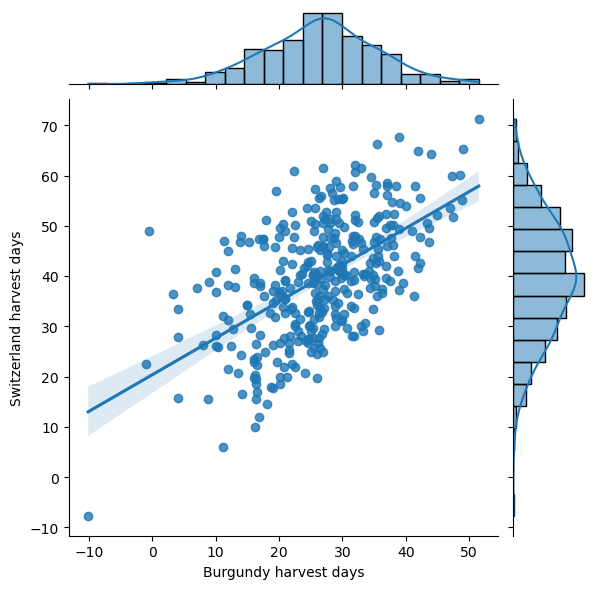

In [50]:
### ANSWER
# 1 point for using jointplot
# 2 points for correct x and y
# 1 point for correct kind
# 2 points for correct x/y labels
sns.jointplot(data = burgundy_switzerland, x = 'harvest_x', y = 'harvest_y', kind="reg")
plt.xlabel("Burgundy harvest days")
plt.ylabel("Switzerland harvest days")

&#9989; **Question:** Correlation is the relationship between two variables: for example, when one variable increases in value, the other increases as well (positive correlation) or when one variable increases in value the other decreases (negative correlation). Variability is how spread the data is or how clustered.

Do you think that harvest date between the two regions is correlated? Positive or negative? How variable is the data? Is the variability constant across harvest dates? What can you learn from your graph?

*Put your response here*

In [52]:
### ANSWER
# 2 points for correctly identifying the positive correlation
# 2 points for correctly identifying data variability.
# 2 points for discussing their understanding. It has to make sense.

---
## Part 2: Modeling grape harvest dates and climate change (**17 points total**)

In this part of the assignment, you'll practice fitting a model to data, much like we did in class with the presidential approval ratings data and the weather data. You will use both `curvefit` and  `polyfit` functions.

In [14]:
# RUN THIS CELL! You'll be using curve_fit for this section of the assignment
from scipy.optimize import curve_fit

### Graphing temperature anomaly vs year and harvest date vs temperature anomaly (3 points)

You have been wondering this whole time: is the temperature increasing with time?

To find out the answer to this question, **below create a scatter plot with "anomaly" on the y-axis and "year" on the x-axis.** Make sure your plots have labels and a title.

In [15]:
## DO NOT DELETE THE PROVIDED LINES OF CODE
## (they are included to make sure you get decent looking plots)
plt.figure(figsize=(15,4))


# Put your code here


<Figure size 1080x288 with 0 Axes>

<Figure size 1080x288 with 0 Axes>

Text(0.5, 1.0, 'Temperature anomaly by year')

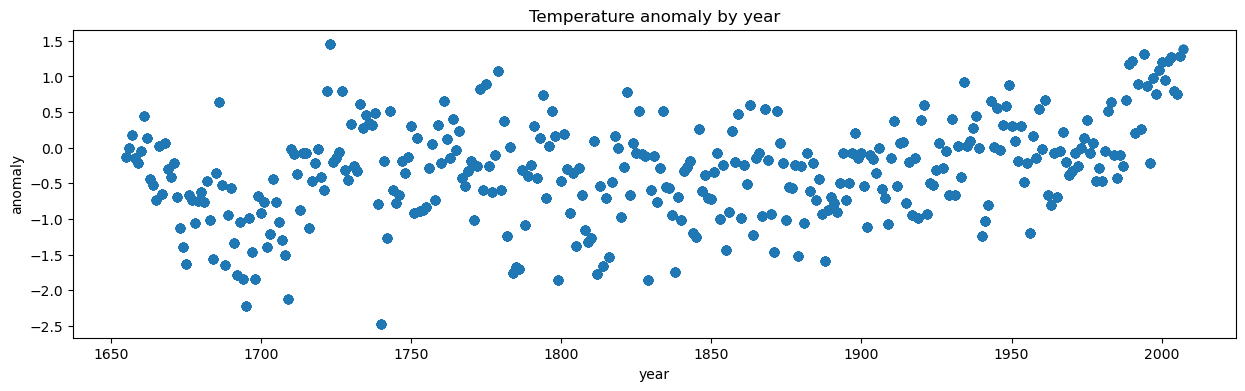

In [51]:
### ANSWER ###

plt.figure(figsize=(15,4))

plt.scatter(x = data['year'], y = data['anomaly'])
plt.xlabel("year")
plt.ylabel("anomaly")
plt.title("Temperature anomaly by year")

You see that indeed, temperature is increasing with time. You want to see if the harvest date is impacted by the temperature anomaly. 

&#9989; **Task:** Create a scatterplot with "harvest date" on the y-axis and "anomaly" on the x-axis.  Make sure your plots have labels and a title

**Hint:** you are plotting lots of data and it will be hard to see the underlying relationship because of overplotting. You can insert the `alpha` argument into the `scatter()` function to create transparency and see your data better. You can start with an alpha as low as 0.1 (e.g., `alpha=0.1`) and adjust it higher if you like.

In [ ]:
## DO NOT DELETE THE PROVIDED LINES OF CODE
## (they are included to make sure you get decent looking plots)
plt.figure(figsize=(8,5))


# Put your code here


Text(0.5, 1.0, 'Harvest date by temperature anomaly')

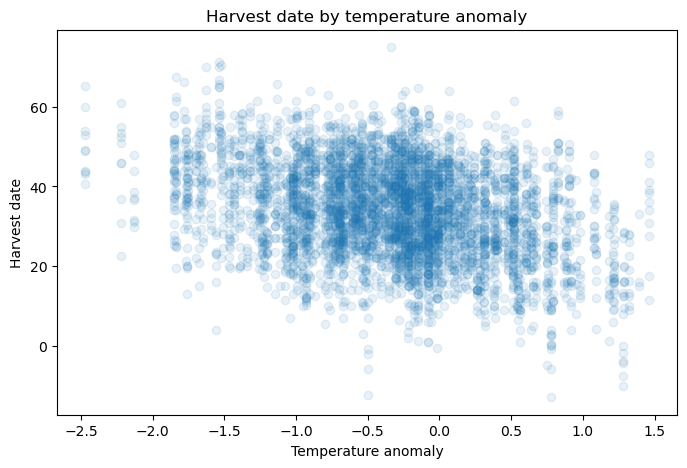

In [55]:
### ANSWER 
# 3 points for axis labels and title
# 2 points for correct inputs in scatter

plt.figure(figsize=(8,5))
plt.scatter(x = data['anomaly'], y = data['harvest'], alpha=0.1)
plt.xlabel("Temperature anomaly")
plt.ylabel("Harvest date")
plt.title("Harvest date by temperature anomaly")

&#9989; **Question:** Based on your graph, is there a correlation between harvest date and temperature anomaly? If so, is it positive or negative?

*Put your response here*

### Modeling harvest date as a function of temperature anomaly `curve_fit` (7 points)

You wonder if "harvest" date can be modeled as a function of temperature "anomaly". You even suspect, after plotting "harvest" vs. "anomaly" above, if this relationship might be linear. You are amazed to learn that in fact others suggest this relationship is linear! In the [publication](https://www.clim-past.net/8/1403/2012/cp-8-1403-2012.pdf) where you got this data from, it suggests that others have found that *for every 1C rise in temperature, harvest date is on average 10 days earlier!*

You set out to create a linear model predicting "harvest" as a function of "anomaly" using `curve_fit`. Your first step is to define a linear function, called "harvest_func", that is a linear model. Recall that linear models take the form of $y = m*x + b$, where $y$ is $harvest$, $x$ is $anomaly$, $m$ is the slope, and $b$ the intercept.

Define your function "harvest_func" so that the inputs are $anomaly$, $m$, and $b$. It should return $anomaly$*$m$ + $b$

In [ ]:
# Define your linear function, "harvest func", here:


In [18]:
### ANSWER
def harvest_func(anomaly, m, b):
    return anomaly*m + b

Our next step is to use Scipy's `curve_fit` function to estimate our parameter values. You should review the documentation for `curve_fit`, which you can find [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html).

We can use the "anomaly" column from our dataset as the "x" values for the function, and the "harvest" column as our "y" values. **Use curve_fit to estimate the values of the parameters in the model: $m$ and $b$; and print out the values!** Make sure you include the right import command so that you can use curve_fit!

Once you have your estimated parameter values, **use them to compute the expected values of $harvest$ for the range of times spanned in the data.**


In [ ]:
# Call the curve_fit function here

# Use your population function and fitted parameter values to get the expected values


In [19]:
### ANSWER
from scipy.optimize import curve_fit

popt, pcov = curve_fit(harvest_func, data["anomaly"], data["harvest"])

m = popt[0]
b = popt[1]

harvest_pred = harvest_func( np.linspace(min(data['anomaly']), max(data['anomaly']), 1000), m, b)

print(m,b)


-5.656973497064281 32.048523825543725


Now that you've used curve_fit to estimate the parameters values and compute the expected values for $harvest$, **plot the actual data and overplot the model values in the cell below.** Make sure you include appropriate labels! Additionally, be sure to plot the actual data and predicted data in contrasting colors that are visible! Remember to use $alpha$ argument in the $scatter()$ function to help with overplotting and visualization ($alpha=0.1$ is a good place to start).

Your graph should look something like the one below:

<img src="https://i.imgur.com/XUodNjp.png" width=600px>

In [ ]:
## DO NOT DELETE THE PROVIDED LINES OF CODE
## (they are included to make sure you get decent looking plots)
plt.figure(figsize=(8,5))


# Put your code here


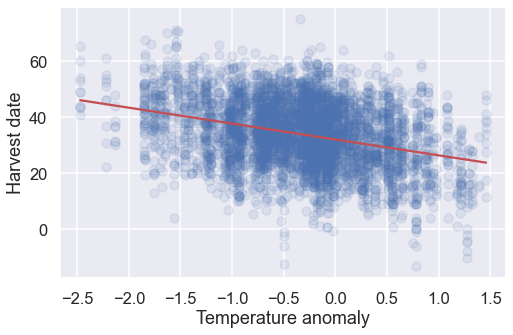

In [20]:
### ANSWER

plt.figure(figsize=(8,5))
plt.scatter(data['anomaly'], data['harvest'], alpha=0.1)
plt.plot( np.linspace(min(data['anomaly']), max(data['anomaly']), 1000), harvest_pred, color="r")
plt.xlabel("Temperature anomaly")
plt.ylabel("Harvest date")
#plt.savefig("curve_fit.png")
plt.show()

**Question:** What do the parameter values tell you about how many days harvest is delayed or comes early for each change in degree Celsius? When there is no temperature anomaly, how many days after August 31st are grapes harvested?

*Put your answer here*

**Question**: Do you think a linear model is appropriate for this data? What do you think about the "fit" of the data to your model?

*Put you answer here*

### Graphing harvest date vs year (2 point)

Instead of wondering if harvest is related to temperature, you wonder what the overall trend in grape harvests will be with climate change. Afterall, you are betting on increasing temperatures to plant your vineyard in Traverse City!

**Below, make a plot of "harvest" vs. "year". Again, use the $alpha$ argument to prevent overplotting and visualize the data better.**

In [ ]:
## DO NOT DELETE THE PROVIDED LINES OF CODE
## (they are included to make sure you get decent looking plots)
plt.figure(figsize=(15,4))


# Put your code here


Text(0.5, 1.0, 'Harvest date by year')

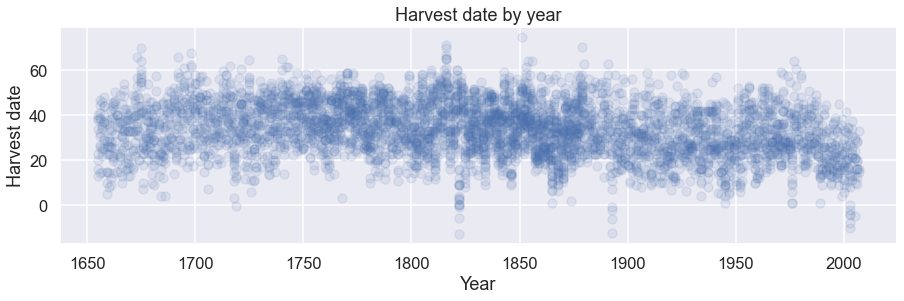

In [21]:
### ANSWER ### 

plt.figure(figsize=(15,4))
plt.scatter(x = data['year'], y = data['harvest'], alpha=0.1)
plt.xlabel("Year")
plt.ylabel("Harvest date")
plt.title("Harvest date by year")

### Modeling harvest date as a function year `polyfit` (5 points)

You doubt that a linear model is appropriate for modeling "harvest" as a function of "year". The response of grapevines in their harvest date to temperature is linear, but you remember that the increases in the earth's temperature are like a "hockey stick", sharply going upwards in a non-linear fashion.

You decide that you'll fit a polynomial function, using the functions `polyfit` (to estimate parameters) and `poly1d` (to create a function to model predicted results) to model "harvest" as a function of "year".

In the cell below: 

**1) estimate polynomial parameters (you must decide on the order of the polynomial function) using `polyfit`**

**2) create a function with these parameters using `poly1d` to create expected values for "harvest" for the minimum and maximum values of "year" in the dataset**

**3) plot out the actual data along with the modeled data values in contrasting colors.**

**4) print out the parameter values**


In [ ]:
### Put your code here


[-1.74249925e-12  1.90389887e-08 -8.66130103e-05  2.09992633e-01
 -2.86176961e+02  2.07852762e+05 -6.28582377e+07]


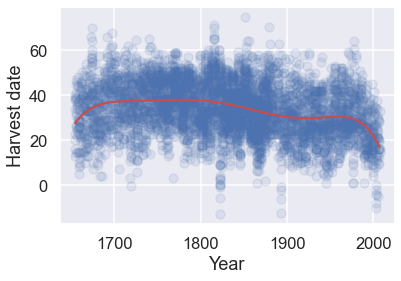

In [22]:
### ANSWER ### 

import numpy as np

N = np.polyfit(data['year'], data['harvest'],6)

func = np.poly1d(N)
plt.scatter(data['year'], data['harvest'], alpha=0.1)
plt.plot(np.linspace(min(data['year']), max(data['year']), 1000),func(np.linspace(min(data['year']), max(data['year']), 1000)), color="r")
plt.xlabel("Year")
plt.ylabel("Harvest date")

print(N)


In the cell below, explain why you chose the order of the polynomial function that you did

*Put your answer here.*

In [5]:
import folium
from IPython.display import display
# Data
locations = ["Alsace", "Auvergne", "Auxerre-Avalon", "Beaujolais and Maconnais", "Bordeaux", "Burgundy", "Champagne 1", "Champagne 2", "Gaillac- South-West", "Germany", "High Loire Valley", "Ile de France", "Jura", "Languedoc", "Low Loire Valley", "Luxembourg", "Maritime alps", "Northern Italy", "Northern Lorraine", "Northern Rhône valley", "Savoie", "Spain", "Southern Lorraine", "Southern Rhône valley", "Switzerland (Leman Lake)", "Various South-East", "Vendée - Poitou Charente"]
latitudes = [48.17, 45.58, 47.78, 46.24, 45.18, 47.32, 49.04, 47.98, 43.9, 48.77, 47.07, 48.93, 46.93, 43.6, 47.15, 49.67, 43.5, 46.22, 48.68, 45.48, 45.6, 42.34, 47.98, 43.98, 46.57, 43.74, 46.45]
longitudes = [7.28, 3.17, 3.57, 4.58, -0.75, 5.04, 3.97, 4.28, 1.9, 9.17, 2, 2.23, 5.88, 3.87, 0.22, 6.13, 6, 10.17, 5.88, 4.83, 6, -3.3, 5.88, 5.05, 6.52, 3.47, -1.5]

# Create a base map
m = folium.Map(location=[47, 5], zoom_start=5)

# Add markers for each wine region
for location, lat, lon in zip(locations, latitudes, longitudes):
    folium.Marker([lat, lon], tooltip=location).add_to(m)

# Display the map
display(m)

---
## Assignment wrap-up

Please fill out the form that appears when you run the code below.  **You must completely fill this out in order to receive credit for the assignment!**

In [ ]:
from IPython.display import HTML
HTML(
"""
<iframe 
	src="https://forms.gle/T8NJkoSVptyz4Hji8" 
	width="800px" 
	height="600px" 
	frameborder="0" 
	marginheight="0" 
	marginwidth="0">
	Loading...
</iframe>
"""
)

---

### Congratulations, you're done!

Submit this assignment by uploading it to the course Desire2Learn web page.  Go to the "Homework Assignments" folder, find the submission link for Homework #5, and upload it there.